In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("heart.csv")

In [3]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
X=df.iloc[:,:-1]
Y=df.iloc[:,-1]

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3, random_state=42)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)

LogisticRegression()

In [8]:
Y_pred=model.predict(X_test)

In [9]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
score=accuracy_score(Y_test,Y_pred)
report=classification_report(Y_test,Y_pred)


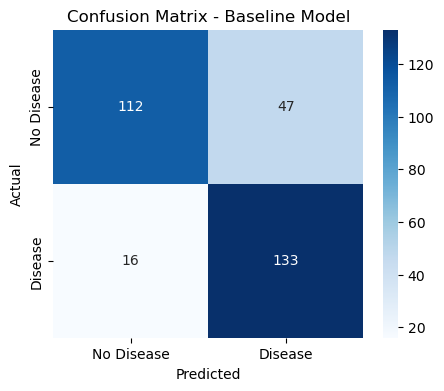

In [10]:
cm_baseline = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Baseline Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [11]:
# hyper parameter tuning 
from sklearn.model_selection import GridSearchCV

parameters = [
    {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['lbfgs', 'sag'], 'class_weight': ['balanced'], 'max_iter': [200, 500]},
    {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['saga'], 'class_weight': ['balanced'], 'max_iter': [200, 500]},
    {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'solver': ['saga'], 'l1_ratio': [0.1, 0.5, 0.9], 'class_weight': ['balanced'], 'max_iter': [200, 500]}
]
grid=GridSearchCV(LogisticRegression(), param_grid=parameters, cv=5 )
grid.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid=[{'C': [0.1, 1, 10], 'class_weight': ['balanced'],
                          'max_iter': [200, 500], 'penalty': ['l2'],
                          'solver': ['lbfgs', 'sag']},
                         {'C': [0.1, 1, 10], 'class_weight': ['balanced'],
                          'max_iter': [200, 500], 'penalty': ['l1'],
                          'solver': ['saga']},
                         {'C': [0.1, 1, 10], 'class_weight': ['balanced'],
                          'l1_ratio': [0.1, 0.5, 0.9], 'max_iter': [200, 500],
                          'penalty': ['elasticnet'], 'solver': ['saga']}])

In [12]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)



Best Params: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 200, 'penalty': 'l1', 'solver': 'saga'}
Best CV Score: 0.8521464646464647


In [13]:
Y_best_pred=grid.predict(X_test)

In [14]:
score_b=accuracy_score(Y_test,Y_best_pred)
report_b=classification_report(Y_test,Y_best_pred)


In [15]:

print(score_b)
print(report_b)

0.8116883116883117
              precision    recall  f1-score   support

           0       0.89      0.72      0.80       159
           1       0.75      0.91      0.82       149

    accuracy                           0.81       308
   macro avg       0.82      0.81      0.81       308
weighted avg       0.83      0.81      0.81       308



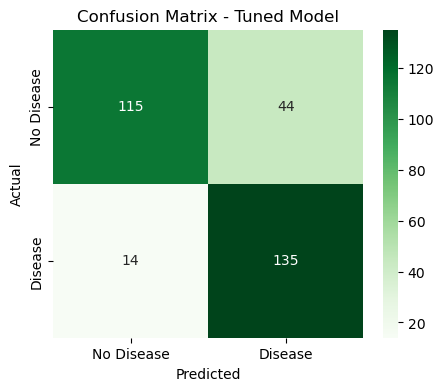

In [16]:
cm_tuned = confusion_matrix(Y_test, Y_best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Tuned Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
import joblib
joblib.dump(grid,"Heart_Disease_model.pkl")
joblib.dump(scaler,"Scaler.pkl")

['Scaler.pkl']